# Mobile price classification project

we will try to predict the class of prices of a mobile phone based on its features

## Machine learning 

1. Problem definition
2. Data analysis
    1. Exploratory data analysis (EDA)
    2. Data Evaluation
    3. Features
3. Machine learning algorithm
    1. Model selection
    2. Model training
    3. Model evaluation
    4. Model comparison
    5. Model hyperparameter-tuning
    6. Feature importance
    7. cross-validation
    8. reporting/summarizing  
4. Experimentation



## 1. Problem definition
 sales data of mobile phones of various companies.find out some relation between features of a mobile phone(eg:- RAM,Internal Memory etc) and its selling price.

## 2. Data analysis
Data is take from [kaggle](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification?select=train.csv)

Data is a classification problem where we are supposed to predict the class of cell-phone prices, we are not aware of the actual prices and would rather be working with ranges of prices, hence this is a `classification` proble and not  `regression` problem

### Importing useful libraries

In [71]:
#importing libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### LOADING THE DATA

In [72]:
from pathlib import Path

DATA_DIR = Path('DATA')
train_data = pd.read_csv(DATA_DIR / 'train.csv')
train_data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [73]:
test_data = pd.read_csv('data/test.csv')
test_data

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


## 2.1 exporatory data analysis (EDA)
we are simply exploring the data. here we are seeing how the data is interconnected, such as how 1 variable or column is connected or causing an impat on our target varriable/label.

There is no set rule or series of steps to do this

Our objective is to get familiar with the data.

In [74]:
train_data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [75]:
train_data.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [76]:
train_data.price_range.value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

data is balanced between portable ouputs, and not dominated by one category or class

In [77]:
# Normalized value counts 
train_data.price_range.value_counts(normalize=True)

price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64

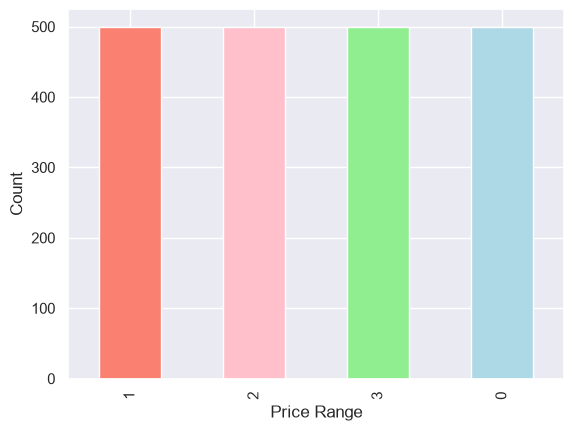

In [78]:
train_data.price_range.value_counts().plot(
    kind='bar', color=['salmon', 'pink', 'lightgreen', 'lightblue'], xlabel='Price Range', ylabel='Count'
);

In [79]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [80]:
## to deal with a null value if have
#train_data.dropna()
#train_data.fillna()
#train_data.isna().sum()

In [81]:
train_data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [82]:
pd.crosstab(index=train_data.blue, columns=train_data.price_range)

price_range,0,1,2,3
blue,,,,
0,257,255,257,241
1,243,245,243,259


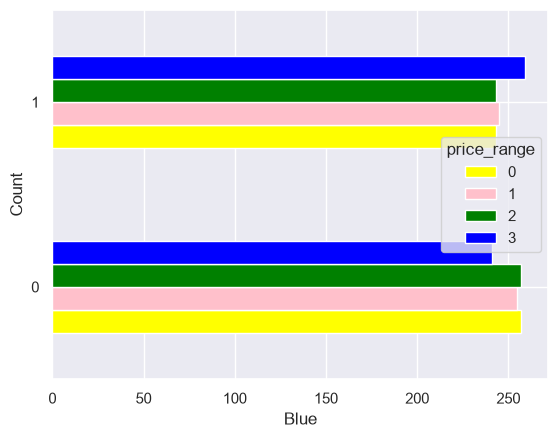

In [83]:
pd.crosstab(index=train_data.blue, columns=train_data.price_range).plot(kind='barh', color=['yellow', 'pink', 'green', 'blue'], xlabel='Blue', ylabel='Count');

In [84]:
pd.crosstab(index=train_data.dual_sim, columns=train_data.price_range)

price_range,0,1,2,3
dual_sim,,,,
0,250,245,251,235
1,250,255,249,265


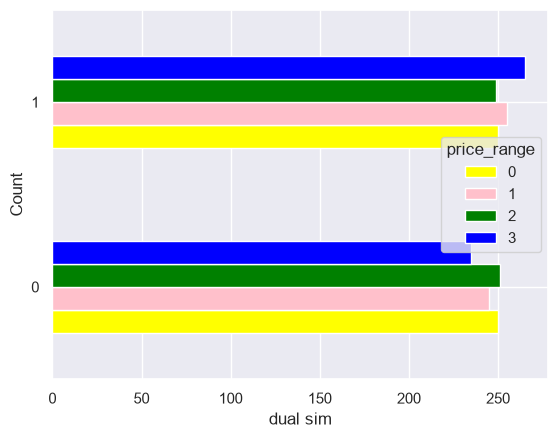

In [85]:
pd.crosstab(index=train_data.dual_sim, columns=train_data.price_range).plot(kind='barh', color=['yellow', 'pink', 'green', 'blue'], xlabel='dual sim', ylabel='Count');

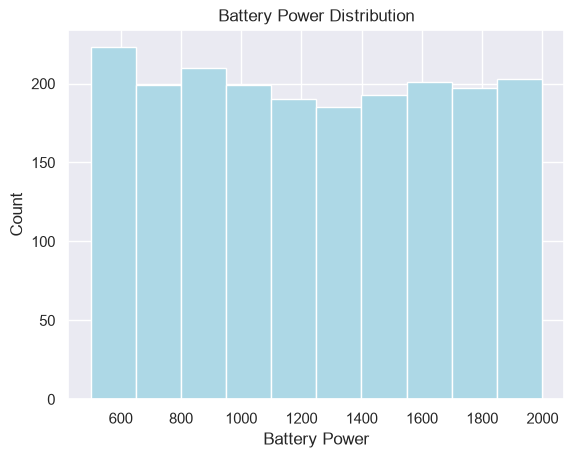

In [86]:
train_data.battery_power.plot.hist(color='lightblue', xlabel='Battery Power', ylabel='Count', title='Battery Power Distribution');

In [87]:
corr_matrix = train_data.corr()
corr_matrix

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


<Axes: >

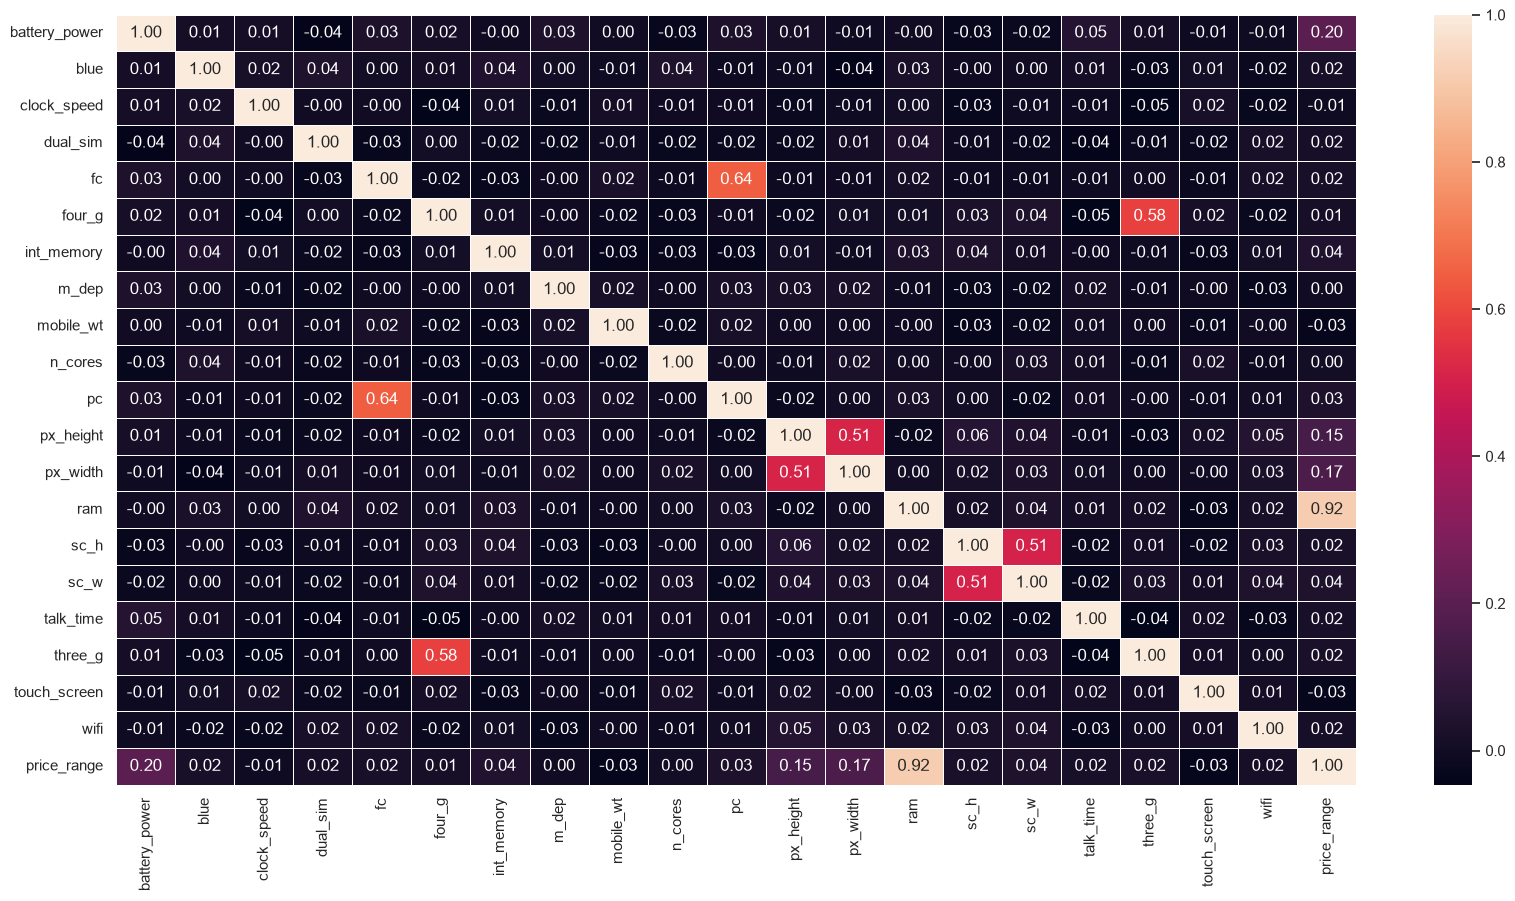

In [88]:
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', linewidths=0.5)

## 2.2 Features
splitting the features and labels

In [89]:
x_train = train_data.drop('price_range', axis=1)
y_train = train_data.price_range

(x_train, y_train)

(      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
 0               842     0          2.2         0   1       0           7   
 1              1021     1          0.5         1   0       1          53   
 2               563     1          0.5         1   2       1          41   
 3               615     1          2.5         0   0       0          10   
 4              1821     1          1.2         0  13       1          44   
 ...             ...   ...          ...       ...  ..     ...         ...   
 1995            794     1          0.5         1   0       1           2   
 1996           1965     1          2.6         1   0       0          39   
 1997           1911     0          0.9         1   1       1          36   
 1998           1512     0          0.9         0   4       1          46   
 1999            510     1          2.0         1   5       1          45   
 
       m_dep  mobile_wt  n_cores  pc  px_height  px_width   ram  sc_h  sc_

In [90]:
x = train_data.drop('price_range', axis=1)
y = train_data.price_range

In [91]:
x_test = test_data.drop('id', axis=1)
x_test

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,17,644,913,2121,14,8,15,1,1,0
996,609,0,1.8,1,0,0,13,0.9,186,4,2,1152,1632,1933,8,1,19,0,1,1
997,1185,0,1.4,0,1,1,8,0.5,80,1,12,477,825,1223,5,0,14,1,0,0
998,1533,1,0.5,1,0,0,50,0.4,171,2,12,38,832,2509,15,11,6,0,1,0


### One Hot Encoding
One hot encoding is a methadology to convert `strings`, `objects` or `catogories` so our machine learning models cn find patterns in dataset.
One hot encoding will be performed on the car data so we can see how it functions

### Data
Contains details of cars and their various features  
Dataset is available on [kaggle](https://www.kaggle.com/datasets/athirags/car-data)

In [92]:
#loading dataset
car_data = pd.read_csv("data/cardata.csv")
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [93]:
# CHECKING DATA TYPES
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [98]:
x_car = car_data
x_car.shape

(301, 9)

In [96]:
# turning the categories/objects into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"]
one_hot = OneHotEncoder() 
transformer = ColumnTransformer([("one_hot",
                                   one_hot,
                                   categorical_features)],
                                   remainder="passthrough")

transformed_x = transformer.fit_transform(x_car)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2419 stored elements and shape (301, 110)>

In [97]:
transformed_x.shape

(301, 110)

In [99]:
x_car_data = car_data

In [100]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                   one_hot,
                                   categorical_features)],
                                   remainder="passthrough")

transformed_x = transformer.fit_transform(x_car_data)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2419 stored elements and shape (301, 110)>

In [102]:
(transformed_x.shape, x_car_data.shape)

((301, 110), (301, 9))

In [105]:
x_car_df = pd.DataFrame(transformed_x.toarray())
x_car_df

,0,1,2,3,4,5,6,7,8,9,...,100,101,102,103,104,105,106,107,108,109
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2014.0,3.35,5.59,27000.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2013.0,4.75,9.54,43000.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2017.0,7.25,9.85,6900.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2011.0,2.85,4.15,5200.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2014.0,4.60,6.87,42450.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2016.0,9.50,11.60,33988.0,0.0
297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2015.0,4.00,5.90,60000.0,0.0
298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2009.0,3.35,11.00,87934.0,0.0
299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2017.0,11.50,12.50,9000.0,0.0


### problem1
data doesnt have a column for `price_range` in test dataset, hence it cant be evaluated. so, we use `test_rain_split` function from `sklearn` to help us use the training dataset for both training and testing

In [ ]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

#spiliting the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

## 3. Machine learning algorithm
## 3.1 Model selection
we can choose our model wiht the help of this image available on cikit-learn.org website.
![image](images/ml_map.svg)


In [ ]:
#importing correct models
#importing linearSVC, KNeighborsClassifier, RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

In [ ]:
# creating a dictionary of models
models = {
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'Linear SVC': LinearSVC()
}

In [ ]:
#creating a function to train and evaluate models
def fit_and_score(models, x_train, x_test, y_train, y_test):
    """
    Fits (trains) and scores (evaluates) the entered machine learning models.
    args:
    models: a dict of different Scikit-Learn machine learning models
    x_train: training data (no labels)
    x_test: testing data (no labels)
    y_train: training labels
    y_test: testing labels
    """

    # set random seed
    np.random.seed(42)
    # make a dictionary to keep model scores
    model_scores = {}
    
    # loop through models
    for name, model in models.items():
        # fit the model to the data
        model.fit(x_train, y_train)
        # evaluate the model and append its score to model_scores
        model_scores[name] = model.score(x_test, y_test)
    return model_scores

In [ ]:
#testing the function
model_scores = fit_and_score(models=models, x_train=x_train, x_test=x_test, y_train=y_train, y_test=y_test)
model_scores  

### Cross validation for KNeightboursClassifier
Cross validation is used to make sure that our data is not biased when training. 

Learning the parameters of a prediction function and testing it on the same data is a methodological mistake: a model that would just repeat the labels of the samples that it has just seen would have a perfect score but would fail to predict anything useful on yet-unseen data. This situation is called overfitting. To avoid it, it is common practice when performing a (supervised) machine learning experiment to hold out part of the available data as a test set X_test, y_test.
[Scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html)

In [ ]:
x = train_data.drop('price_range', axis=1)
y = train_data.price_range
print(x) 
print(y)

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier  
import numpy as np

np.random.seed(42)

knn_model = KNeighborsClassifier()
scores = cross_val_score(knn_model, x, y, cv=5)
scores

### Hyper parameter tuning 
there are 3 ways to perform hyperparameter tuning with Scikit learn
1. Manual
2. RandomSearchCV
3. GridSearchCV

#### Manual hyperparameter tuning

In [ ]:
knn_model.get_params()

In [ ]:
# create a list of train scores, test scores and different values for n_neighbors
train_scores = []
test_scores = []
neighbors = range(1, 21)

#setup KNN instance
knn_model = KNeighborsClassifier()

# loop through diff neighbors
for i in neighbors:
    knn_model.set_params(n_neighbors=i)
    
    #fit the model
    knn_model.fit(x_train, y_train)
    
    #update the train scores list
    train_scores.append(knn_model.score(x_train, y_train))
    
    #update the test scores list
    test_scores.append(knn_model.score(x_test, y_test))

In [ ]:
train_scores, test_scores

In [ ]:
plt.plot(neighbors, train_scores, label='Train Score')
plt.plot(neighbors, test_scores, label='Test Score')
plt.xlabel('Number of Neighbors')
plt.ylabel('Score')
plt.title('KNN Model Performance')
plt.xticks(np.arange(1, 21, 1))
plt.legend()

plt.show()

#### RANDOM AND GRID SEARCH CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [ ]:
# RandomSearchCV

knn_rand_grid = {
    "n_neighbors": np.arange(1, 21),
    "weights": ["uniform", "distance"],
    "p" : [1, 2, 1.5]
}

In [ ]:
np.random.seed(42)
rs_knn = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=knn_rand_grid, cv=5, n_iter=20, verbose=True)

#fit the random hyperparameter search model
rs_knn.fit(x_train, y_train)

In [ ]:
rs_knn.best_params_

In [ ]:
rs_knn.score(x_test, y_test)

In [ ]:
# GridSearchCV

knn_grid_grid = {
    "n_neighbors": np.arange(1, 21),
    "weights": ["uniform", "distance"],
    "p" : [1, 2, 1.5]
}

In [ ]:
np.random.seed(42)

gs_knn = GridSearchCV(KNeighborsClassifier(), 
                       param_grid=knn_grid_grid,
                       cv=5,
                       verbose=True)

#fit the grid hyperparameter search model
gs_knn.fit(x_train, y_train)

In [ ]:
gs_knn.best_params_

In [ ]:
gs_knn.score(x_test, y_test)

## Evaluation
 we will see evaluation of some metrics other than accuracy
- ROC and AUC --> ( for binary classification only)
- confusion Matrix
- Precision, Recall and F1-score

## Predictions

In [ ]:
y_preds = gs_knn.predict(x_test)
y_preds

In [ ]:
np.array(y_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# confusion matrix
sns.set(font_scale=1)
def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")

In [ ]:
plot_conf_mat(y_test=y_test, y_preds=y_preds)

In [ ]:
# classification report
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_preds))

checking best hyperparameter scores

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
gs_knn

In [ ]:
cv_acc = cross_val_score(gs_knn,
                         x, y,
                         cv=5, 
                         scoring='accuracy')

cv_acc

In [ ]:
cv_acc.mean() * 100


# Feature Importance
which features matter the most? 

for our problem it could be something like, which feature of a mobile contribute the most to its cost and price class.


## Saving the model

> we will be using ``joblib``


In [ ]:
!pip install joblib

In [ ]:
# saving the model WITH JOBLIB
import joblib

joblib.dump(gs_knn, "mobile-price-cls-model.joblib")

## Loading the model
load with the help of `joblib`

In [ ]:
# loading the model with joblib
import joblib
loaded_model = joblib.load("mobile-price-cls-model.joblib")
loaded_model

### testing 
> testing the loaded model with saved model

In [ ]:
y_gs_knn_preds = gs_knn.predict(x_test)
y_loaded_preds = loaded_model.predict(x_test)

In [ ]:
y_gs_knn_preds == y_loaded_preds

In [ ]:
(y_gs_knn_preds, y_loaded_preds)